# Gait as a Window into the Brain
### Psychointelligence: detecting cognitive decline, falls and frailty from how a person walks

**Dataset:** GSTRIDE  ·  163 older adults  ·  **Built in Google Colab**

Every step explains *what* we are doing and *why*

**Steps Overview:**
1. Load and look at the raw data
2. Clean it properly
3. Visualise it with doughnut charts
4. Remove redundant (overlapping) features
5. Train three algorithms on three tasks
6. Measure how well they did
7. Read what the best model learned
8. Show how the three tasks relate

> **The big idea:** walking is not fully automatic. Staying steady needs attention, planning and balance, which are all brain jobs. So when the brain starts to struggle, the walk quietly changes. We test whether a machine can pick that up.

## Step 0 — Set up our tools

We load the libraries and define a house style

In [ ]:
import pandas as pd, numpy as np, re, warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate, cross_val_predict, StratifiedKFold
from sklearn.metrics import roc_curve, auc, confusion_matrix
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm

RANDOM_STATE = 42

# ---- house style ----
INK="#243746"; PRIMARY="#0B6E99"; TEAL="#1C7293"; AMBER="#E08A2B"
POS="#C43E3E"; NEG="#2E86AB"; GREEN="#2E8B57"; PURPLE="#7D5BA6"; GREY="#AEB9C2"
CATS=[PRIMARY, AMBER, TEAL, POS, GREEN, PURPLE]
plt.rcParams.update({"font.size":11, "axes.titlesize":13, "axes.titleweight":"bold",
                     "axes.edgecolor":"#C9D3DA", "axes.labelcolor":INK,
                     "text.color":INK, "xtick.color":INK, "ytick.color":INK,
                     "figure.facecolor":"white", "axes.facecolor":"white"})

def style_ax(ax):
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

def doughnut(ax, sizes, labels, colors, title, center_text):
    ax.pie(sizes, labels=labels, colors=colors, startangle=90,
           autopct=lambda p: f"{p:.0f}%", pctdistance=0.75, labeldistance=1.12,
           wedgeprops=dict(width=0.42, edgecolor="white", linewidth=2),
           textprops=dict(fontsize=10, color=INK))
    ax.text(0, 0, center_text, ha="center", va="center", fontsize=13, fontweight="bold", color=INK)
    ax.set_title(title, fontsize=12, fontweight="bold", color=INK, pad=8)

def hbar(ax, labels, values, colors, title, xlabel):
    ax.barh(labels, values, color=colors)
    ax.set_title(title); ax.set_xlabel(xlabel); style_ax(ax)
    ax.invert_yaxis()

print("Tools ready.")

Tools ready.


## Step 1 — Load the data

Upload the data `Database_register.xlsx` 163 people record

In [ ]:
# Find the data file whether we are running from the repo, from Colab, or from a subfolder.
import os

CANDIDATES = [
    "data/Database_register.xlsx",           # running from repo root
    "../data/Database_register.xlsx",        # running from notebooks/
    "/content/Database_register.xlsx",       # Google Colab upload
    "Database_register.xlsx",                # same folder
]
DATA_PATH = next((p for p in CANDIDATES if os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find Database_register.xlsx.\n"
        "From the repo it lives in data/. In Colab, upload it to /content/ "
        "or set DATA_PATH manually."
    )
print("Using data file:", DATA_PATH)

def load_register(path):
    if str(path).lower().endswith(".csv"):
        full = pd.read_csv(path, sep=";", encoding="cp1252", header=None)
    else:
        full = pd.read_excel(path, header=None)
    colnames = full.iloc[1].tolist()
    data = full.iloc[3:].copy()
    data.columns = colnames
    data = data.dropna(how="all").reset_index(drop=True)
    return data, colnames

df, cols = load_register(DATA_PATH)
print(f"Loaded {df.shape[0]} people, each described by {df.shape[1]} columns.")

Loaded 163 people, each described by 60 columns.


## Step 2 — A first look at the raw data

Two questions matter most at the start:
- **How complete is the data?** (missing values cause trouble later)
- **What do a few rows actually look like?**

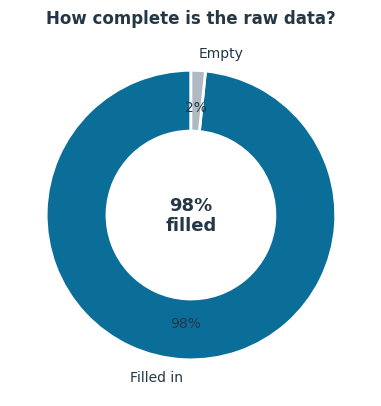

Most columns are complete. The few gaps are handled in Step 7.


In [ ]:
# a tiny helper to find columns by keyword (the names have odd spacing)
def one(key):
    hits = [c for c in cols if isinstance(c, str) and key.lower() in c.lower()]
    return hits[0] if hits else None
def num(c):
    return pd.to_numeric(df[c], errors="coerce")

# how full is the whole table?
total_cells = df.shape[0] * df.shape[1]
filled = df.notna().sum().sum()
missing = total_cells - filled

fig, ax = plt.subplots(figsize=(4.2, 4.2))
doughnut(ax, [filled, missing], ["Filled in", "Empty"], [PRIMARY, GREY],
         "How complete is the raw data?", f"{100*filled/total_cells:.0f}%\nfilled")
plt.tight_layout(); plt.show()

print("Most columns are complete. The few gaps are handled in Step 7.")

## Step 3 — Clean the data

Real data always has small messes. We fix three:

1. **The fall label** has a stray space (`"NO "` vs `"NO"`), which would split one group into two. We trim it and turn Yes/No into 1/0.
2. **Age** is stored as bands like `70-74`. We use the middle value (72).
3. We build our **three yes/no targets** (the things we will try to predict).

The three targets:
- **Dementia** = signs of cognitive decline (a score called GDS of 3 or more)
- **Falls** = fell in the last year
- **Frailty** = physically frail (a score called Fried of 2 or more)

In [ ]:
def age_midpoint(v):
    ns = re.findall(r"\d+", str(v))
    return np.mean([int(x) for x in ns]) if ns else np.nan

gds   = pd.to_numeric(df[one("Global Deterioration")], errors="coerce")
fried = pd.to_numeric(df[one("Frailty assessment")], errors="coerce")
fall_raw = df[one("Falls during the last year")]
print("Fall label BEFORE cleaning:", list(fall_raw.unique()))
fall = fall_raw.astype(str).str.strip().str.upper().map({"YES":1, "NO":0})
print("Fall label AFTER cleaning :", dict(fall.value_counts()))

TARGETS = {
    "Dementia": (gds  >= 3).astype(int),
    "Falls":    fall.astype(int),
    "Frailty":  (fried >= 2).astype(int),
}
print("\nTargets built. Positive counts (people who HAVE the condition):")
for name, y in TARGETS.items():
    print(f"  {name:<10} {int(y.sum()):>3} of {len(y)}")

Fall label BEFORE cleaning: ['NO', 'YES', 'NO ']
Fall label AFTER cleaning : {1: np.int64(86), 0: np.int64(77)}

Targets built. Positive counts (people who HAVE the condition):
  Dementia    43 of 163
  Falls       86 of 163
  Frailty     49 of 163


## Step 4 — Visualise the three targets (doughnut charts)

A model's job is easier or harder depending on how **balanced** the groups are. If only a few people have a condition, the model has fewer examples to learn from. These doughnuts show that split for each task.

**How to read them:** the coloured slice is the share of people who *have* the condition. Falls is near an even 50/50, dementia is the most lopsided.

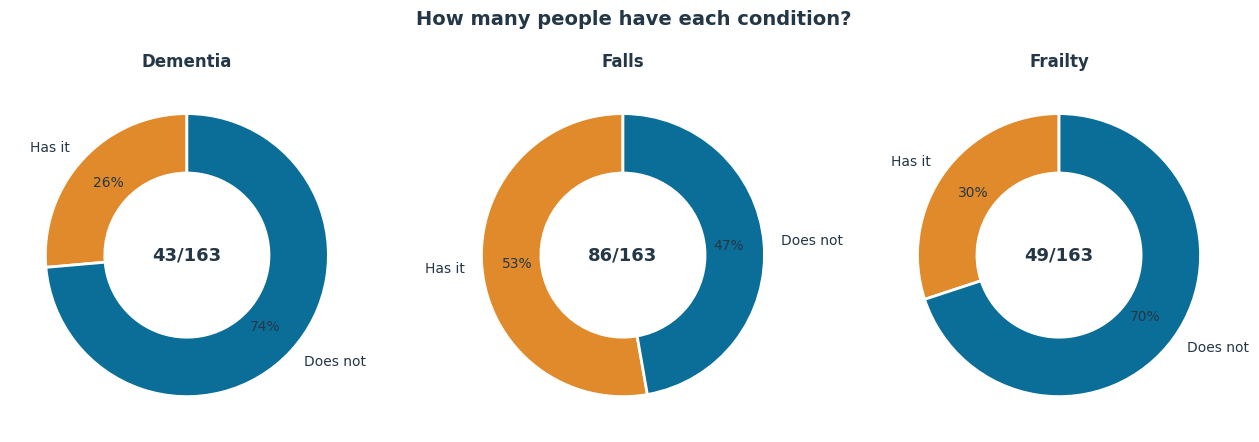

Falls is the most balanced (53% positive); dementia is the rarest (26%).
Rare = harder to learn, so we watch dementia results especially carefully.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.3))
for ax, (name, y) in zip(axes, TARGETS.items()):
    pos = int(y.sum()); neg = len(y) - pos
    doughnut(ax, [pos, neg], ["Has it", "Does not"], [AMBER, PRIMARY],
             name, f"{pos}/{len(y)}")
fig.suptitle("How many people have each condition?", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

print("Falls is the most balanced (53% positive); dementia is the rarest (26%).")
print("Rare = harder to learn, so we watch dementia results especially carefully.")

## Step 5 — Who is in the study?

Knowing the make-up of the group tells us who our conclusions apply to. Two doughnuts and one bar chart:

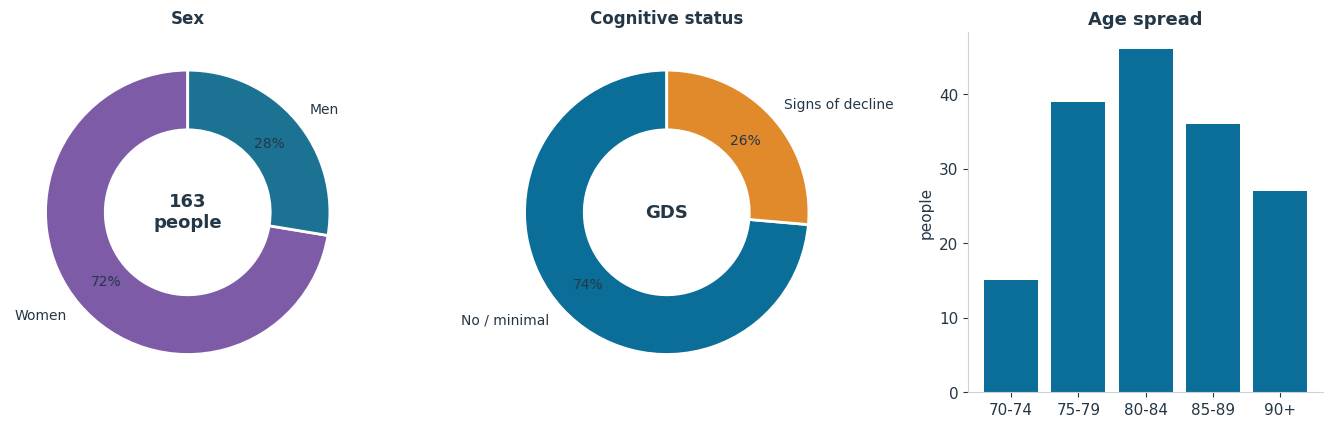

Mostly women, mostly aged 80+, and about a quarter show signs of cognitive decline.


In [ ]:
sex = df[one("Sex")].astype(str).str.strip().str.upper()
sex_counts = sex.value_counts()

# group cognitive stage into an easy two-way split
cog_group = pd.Series(np.where(gds>=3, "Signs of decline", "No/minimal decline"))
cog_counts = cog_group.value_counts()

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4))
doughnut(axes[0], [sex_counts.get("F",0), sex_counts.get("M",0)],
         ["Women", "Men"], [PURPLE, TEAL], "Sex", f"{len(sex)}\npeople")
doughnut(axes[1], [cog_counts.get("No/minimal decline",0), cog_counts.get("Signs of decline",0)],
         ["No / minimal", "Signs of decline"], [PRIMARY, AMBER], "Cognitive status", "GDS")

# age bands as a bar (too many categories for a doughnut)
age_mid = df[one("Age (range")].map(age_midpoint)
bands = pd.cut(age_mid, bins=[69,74,79,84,89,99], labels=["70-74","75-79","80-84","85-89","90+"])
band_counts = bands.value_counts().sort_index()
axes[2].bar(band_counts.index.astype(str), band_counts.values, color=PRIMARY)
axes[2].set_title("Age spread"); axes[2].set_ylabel("people"); style_ax(axes[2])
plt.tight_layout(); plt.show()

print("Mostly women, mostly aged 80+, and about a quarter show signs of cognitive decline.")

## Step 6 — Choose the walking measurements, and remove overlaps

The sensor in the data gives many walking numbers, but some are **the same information in disguise**. For example, walking speed is roughly *stride length x cadence*, so putting all three in confuses the model, like giving it height in centimetres, inches and feet at once.

We start with a candidate list, then run two checks:
- a **correlation heatmap** (which features move together), and
- a **VIF score** (a redundancy meter: above 5 is a warning, above 10 is severe).

Then we keep one clean representative from each overlapping group.

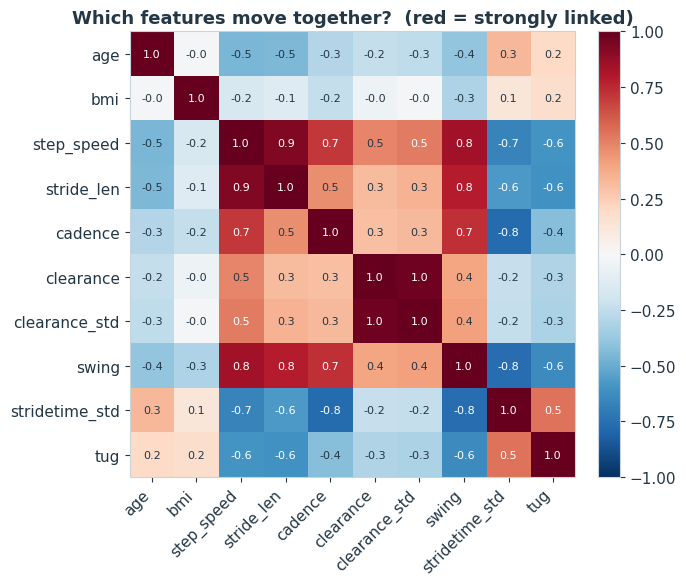

In [ ]:
# candidate features (the full, overlapping set)
cand = pd.DataFrame(index=df.index)
cand["age"]            = age_mid
cand["bmi"]            = num(one("Body-mass"))
cand["step_speed"]     = num(one("Step Speed - Avg"))
cand["stride_len"]     = num(one("Stride Length - Avg"))
cand["cadence"]        = num(one("Cadence - Avg"))
cand["clearance"]      = num(one("Clearance - Avg"))
cand["clearance_std"]  = num(one("Clearance - STD"))
cand["swing"]          = num(one("Swing - Avg"))
cand["stridetime_std"] = num(one("Stride time - STD"))
cand["tug"]            = num(one("TUG test"))

C = cand.fillna(cand.median())

# --- correlation heatmap ---
fig, ax = plt.subplots(figsize=(7.2, 6))
corr = C.corr()
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(C.columns))); ax.set_xticklabels(C.columns, rotation=45, ha="right")
ax.set_yticks(range(len(C.columns))); ax.set_yticklabels(C.columns)
for i in range(len(C.columns)):
    for j in range(len(C.columns)):
        ax.text(j, i, f"{corr.iloc[i,j]:.1f}", ha="center", va="center",
                color="white" if abs(corr.iloc[i,j])>0.5 else INK, fontsize=8)
ax.set_title("Which features move together?  (red = strongly linked)")
plt.colorbar(im, fraction=0.046, pad=0.04); plt.tight_layout(); plt.show()

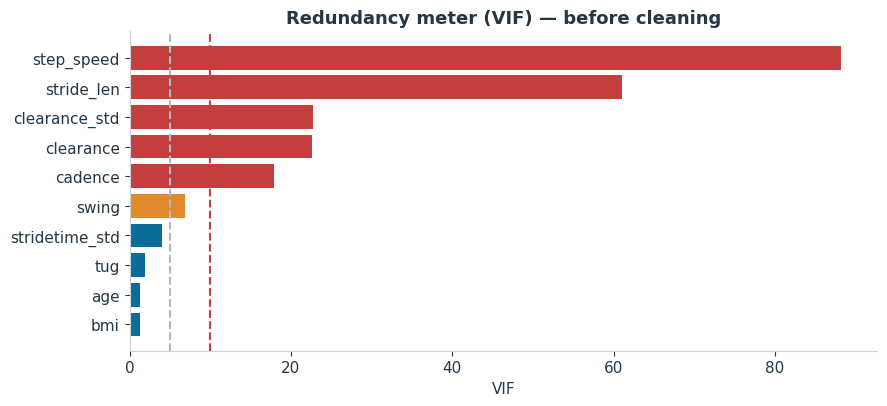

Red bars are badly overlapping features. speed, stride length, cadence and clearance
all carry the same 'how well do they walk' information, so we keep just representatives.


In [ ]:
# --- VIF redundancy meter ---
from sklearn.preprocessing import StandardScaler as _SS
Cs = _SS().fit_transform(C)
vif = pd.DataFrame({"feature": C.columns,
                    "VIF": [variance_inflation_factor(Cs, i) for i in range(Cs.shape[1])]}
                   ).sort_values("VIF", ascending=False)

colors = [POS if v>10 else (AMBER if v>5 else PRIMARY) for v in vif["VIF"]]
fig, ax = plt.subplots(figsize=(9, 4.2))
hbar(ax, vif["feature"], vif["VIF"], colors, "Redundancy meter (VIF) — before cleaning", "VIF")
ax.axvline(5, color=GREY, ls="--"); ax.axvline(10, color=POS, ls="--")
plt.tight_layout(); plt.show()
print("Red bars are badly overlapping features. speed, stride length, cadence and clearance")
print("all carry the same 'how well do they walk' information, so we keep just representatives.")

**The decision.** From the tangled walking cluster we keep two representatives (**step speed** and **foot clearance**), drop the duplicates (stride length, cadence, clearance variability, swing), and keep the independent features (age, BMI, TUG, stride-time variability). This is our **clean feature set of 6**.

In [ ]:
FEATURES = ["age", "bmi", "tug", "step_speed", "clearance", "stridetime_std"]
X = cand[FEATURES].copy()

# confirm the redundancy is gone
Xs_check = _SS().fit_transform(X.fillna(X.median()))
vif2 = pd.DataFrame({"feature": FEATURES,
                     "VIF": [variance_inflation_factor(Xs_check, i) for i in range(len(FEATURES))]})
print("Clean feature set:", FEATURES)
print("\nVIF after cleaning (all should be under 5 now):")
for _, r in vif2.iterrows():
    print(f"  {r['feature']:<16} {r['VIF']:.1f}")

Clean feature set: ['age', 'bmi', 'tug', 'step_speed', 'clearance', 'stridetime_std']

VIF after cleaning (all should be under 5 now):
  age              1.3
  bmi              1.0
  tug              1.7
  step_speed       2.9
  clearance        1.3
  stridetime_std   2.0


## Step 7 — Handle the missing values

A few people are missing the TUG measurement. So we fill each gap with that column's **median** (its middle value), a safe, standard choice. This chart shows below shows the feature missing value.

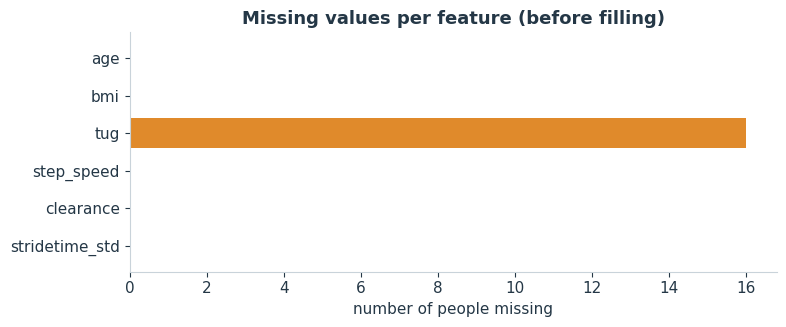

Only TUG has gaps. We fill them with the median inside the modelling pipeline,
so the fill is learned only from training data


In [ ]:
miss = X.isna().sum()
fig, ax = plt.subplots(figsize=(8, 3.4))
hbar(ax, miss.index, miss.values, [AMBER if v>0 else PRIMARY for v in miss.values],
     "Missing values per feature (before filling)", "number of people missing")
plt.tight_layout(); plt.show()
print("Only TUG has gaps. We fill them with the median inside the modelling pipeline,")
print("so the fill is learned only from training data")

## Step 8 — See the signal with your own eyes

Before any model, let's check there is even something to find. These box plots compare the **dementia group** with the **healthy group** on two key measurements.

**How to read a box plot:** the line in the box is the typical (middle) person; the box holds the middle half of people. If the two boxes sit at clearly different heights, the measurement carries a real signal.

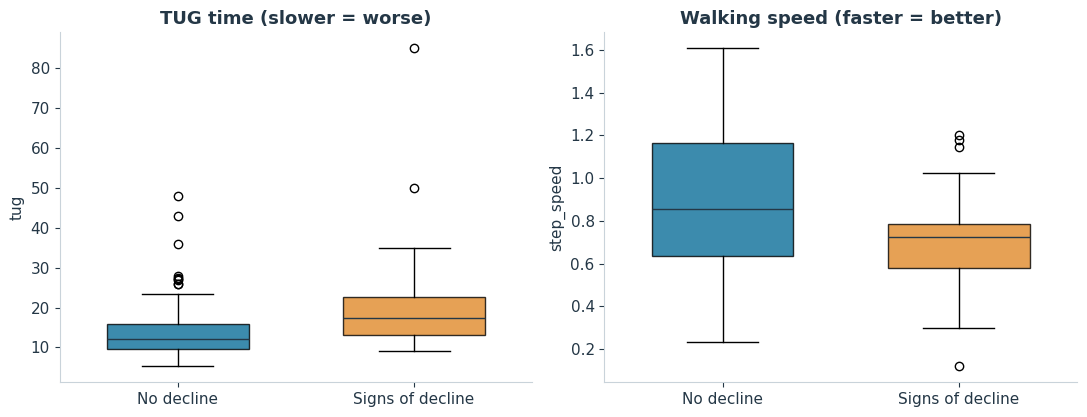

The decline group takes clearly longer on TUG and walks slower. The signal is real,
and visible before we build anything.


In [ ]:
yd = TARGETS["Dementia"]
Xf = X.fillna(X.median())
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
for ax, feat, nice in zip(axes, ["tug","step_speed"], ["TUG time (slower = worse)","Walking speed (faster = better)"]):
    g0 = Xf.loc[yd==0, feat]; g1 = Xf.loc[yd==1, feat]
    bp = ax.boxplot([g0, g1], labels=["No decline","Signs of decline"], patch_artist=True, widths=0.6)
    for patch, col in zip(bp["boxes"], [PRIMARY, AMBER]): patch.set_facecolor(col); patch.set_alpha(0.8)
    for med in bp["medians"]: med.set_color(INK)
    ax.set_title(nice); ax.set_ylabel(feat); style_ax(ax)
plt.tight_layout(); plt.show()
print("The decline group takes clearly longer on TUG and walks slower. The signal is real,")
print("and visible before we build anything.")

## Step 9 — How we train and test fairly

With only 163 people, a single train/test split would be unreliable, one lucky or unlucky draw could mislead us. So we use **5-fold cross-validation**:

1. Split people into 5 equal groups.
2. Train on 4 groups, test on the 1 left out.
3. Rotate so every group gets a turn as the test set.
4. Average the 5 scores. (We repeat the whole thing 10 times to be safe.)

Below is the idea in one picture: amber = the group tested that round, blue = groups used for training.

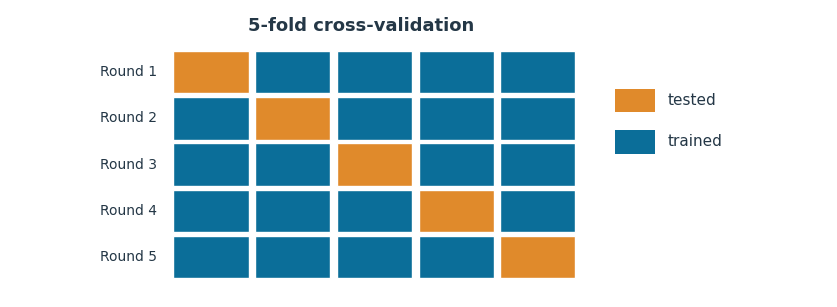

In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 3.2))
n=5
for row in range(n):
    for col in range(n):
        ax.add_patch(Rectangle((col, n-1-row), 0.92, 0.92,
                     facecolor=AMBER if col==row else PRIMARY, edgecolor="white"))
    ax.text(-0.2, n-1-row+0.46, f"Round {row+1}", ha="right", va="center", fontsize=10)
ax.text(2.3, n+0.35, "5-fold cross-validation", ha="center", fontsize=13, fontweight="bold")
ax.add_patch(Rectangle((n+0.4, 3.6), 0.5, 0.5, facecolor=AMBER)); ax.text(n+1.05, 3.85, "tested", va="center")
ax.add_patch(Rectangle((n+0.4, 2.7), 0.5, 0.5, facecolor=PRIMARY)); ax.text(n+1.05, 2.95, "trained", va="center")
ax.set_xlim(-2, n+3); ax.set_ylim(-0.4, n+0.8); ax.axis("off")
plt.tight_layout(); plt.show()

In [ ]:
# The three algorithms (three different 'styles' of learning)
base = [("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]
def make_models():
    return {
        "Logistic Regression": Pipeline(base + [("m", LogisticRegression(
            C=0.5, class_weight="balanced", max_iter=2000))]),
        "Random Forest": Pipeline(base + [("m", RandomForestClassifier(
            n_estimators=300, min_samples_leaf=3, class_weight="balanced",
            random_state=RANDOM_STATE, n_jobs=-1))]),
        "Gradient Boosting": Pipeline(base + [("m", HistGradientBoostingClassifier(
            max_leaf_nodes=8, learning_rate=0.06, max_iter=150,
            l2_regularization=1.0, random_state=RANDOM_STATE))]),
    }
CV = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=RANDOM_STATE)
print("Three algorithms ready:")
print("  1. Logistic Regression - simple and fully explainable")
print("  2. Random Forest        - a voting committee of decision trees")
print("  3. Gradient Boosting    - a perfectionist that fixes its own mistakes")

Three algorithms ready:
  1. Logistic Regression - simple and fully explainable
  2. Random Forest        - a voting committee of decision trees
  3. Gradient Boosting    - a perfectionist that fixes its own mistakes


## Step 10 — Train and compare (3 algorithms x 3 tasks)

We now run every algorithm on every task. The score is **ROC-AUC**: 0.5 is pure guessing, 1.0 is perfect, and around 0.75 is genuinely useful for screening.

**How to read the chart:** taller is better. The thin black lines are the uncertainty, when they overlap, the difference between algorithms is small.

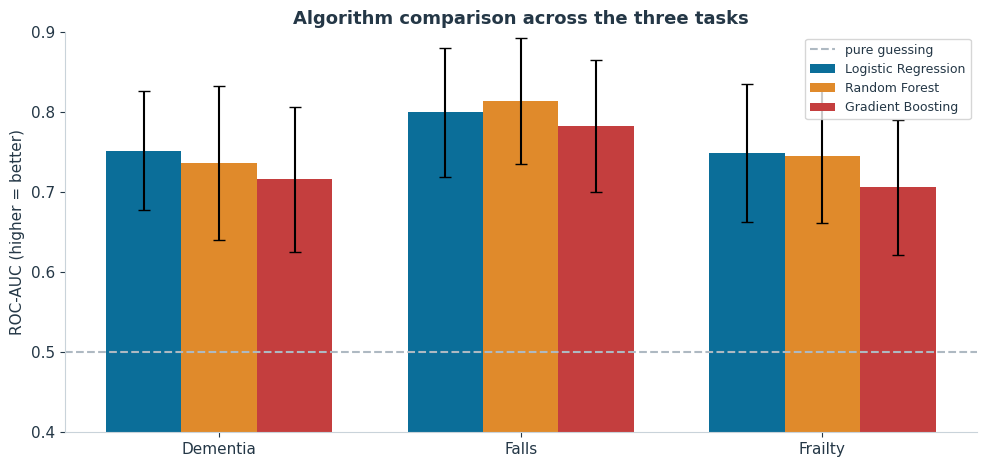

Best algorithm per task:
  Dementia   -> Logistic Regression  AUC 0.752
  Falls      -> Random Forest        AUC 0.814
  Frailty    -> Logistic Regression  AUC 0.749


In [ ]:
results = []
for tname, y in TARGETS.items():
    for mname, model in make_models().items():
        r = cross_validate(model, X, y, cv=CV, scoring=["roc_auc","recall"])
        results.append({"task":tname, "algorithm":mname,
                        "auc":r["test_roc_auc"].mean(), "auc_sd":r["test_roc_auc"].std(),
                        "recall":r["test_recall"].mean()})
res = pd.DataFrame(results)

tasks = list(TARGETS); algos = ["Logistic Regression","Random Forest","Gradient Boosting"]
ALGO_COLORS = [PRIMARY, AMBER, POS]      # blue, orange, RED  <-- new
x = np.arange(len(tasks)); w = 0.25
fig, ax = plt.subplots(figsize=(10, 4.8))
for i, a in enumerate(algos):
    vals = [res[(res.task==t)&(res.algorithm==a)].auc.values[0] for t in tasks]
    err  = [res[(res.task==t)&(res.algorithm==a)].auc_sd.values[0] for t in tasks]
    ax.bar(x+(i-1)*w, vals, w, yerr=err, capsize=4, color=ALGO_COLORS[i], label=a)   # <-- changed
ax.axhline(0.5, ls="--", color=GREY, label="pure guessing")
ax.set_xticks(x); ax.set_xticklabels(tasks); ax.set_ylim(0.4, 0.9)
ax.set_ylabel("ROC-AUC (higher = better)"); ax.set_title("Algorithm comparison across the three tasks")
ax.legend(fontsize=9); style_ax(ax); plt.tight_layout(); plt.show()

best = res.sort_values("auc", ascending=False).groupby("task").first()
print("Best algorithm per task:")
for t in tasks:
    b = best.loc[t]; print(f"  {t:<10} -> {b['algorithm']:<20} AUC {b['auc']:.3f}")

**What the chart shows.** The best algorithm differs by task: the **simple Logistic Regression** wins on dementia and frailty (the rarer conditions), while **Random Forest** wins on falls (the balanced one). The error bars overlap, so treat "best" as a gentle lead, not a knockout. The reassuring message: the *simple, explainable* model is right at the top for our main dementia task.

## Step 11 — A closer look at performance (dementia task)

AUC is one summary number. For a screening tool, two more pictures matter:
- the **ROC curve** (the trade-off between catching cases and raising false alarms), and
- the **confusion matrix** (of real cases, how many did we catch vs miss).

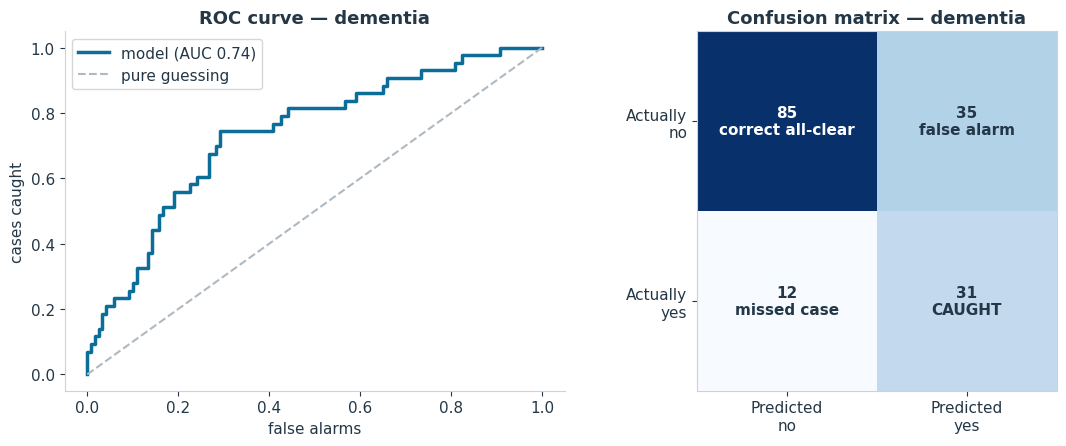

Of 43 people with signs of decline, the model caught 31 and missed 12
  = a catch rate of 72%.


In [ ]:
y = TARGETS["Dementia"]
lr = make_models()["Logistic Regression"]
proba = cross_val_predict(lr, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=1),
                          method="predict_proba")[:,1]
pred = (proba >= 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))

# ROC curve
fpr, tpr, _ = roc_curve(y, proba); roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color=PRIMARY, lw=2.5, label=f"model (AUC {roc_auc:.2f})")
axes[0].plot([0,1],[0,1], ls="--", color=GREY, label="pure guessing")
axes[0].set_xlabel("false alarms"); axes[0].set_ylabel("cases caught")
axes[0].set_title("ROC curve — dementia"); axes[0].legend(); style_ax(axes[0])

# confusion matrix
cm = confusion_matrix(y, pred)
im = axes[1].imshow(cm, cmap="Blues")
axes[1].set_xticks([0,1]); axes[1].set_xticklabels(["Predicted\nno","Predicted\nyes"])
axes[1].set_yticks([0,1]); axes[1].set_yticklabels(["Actually\nno","Actually\nyes"])
labels = [["correct all-clear","false alarm"],["missed case","CAUGHT"]]
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, f"{cm[i,j]}\n{labels[i][j]}", ha="center", va="center",
                     color="white" if cm[i,j]>cm.max()/2 else INK, fontsize=11, fontweight="bold")
axes[1].set_title("Confusion matrix — dementia")
plt.tight_layout(); plt.show()

caught = cm[1,1]; missed = cm[1,0]
print(f"Of {caught+missed} people with signs of decline, the model caught {caught} and missed {missed}")
print(f"  = a catch rate of {100*caught/(caught+missed):.0f}%.")

## Step 12 — What did the model learn? (odds ratios)

Because we used the explainable model, we can read exactly which measurements point to cognitive decline. We show this as **odds ratios**:
- **above 1** (red) = a higher value raises the odds of decline
- **below 1** (blue) = a higher value lowers the odds

Because we cleaned the features first, these bars are now trustworthy and point in sensible directions.

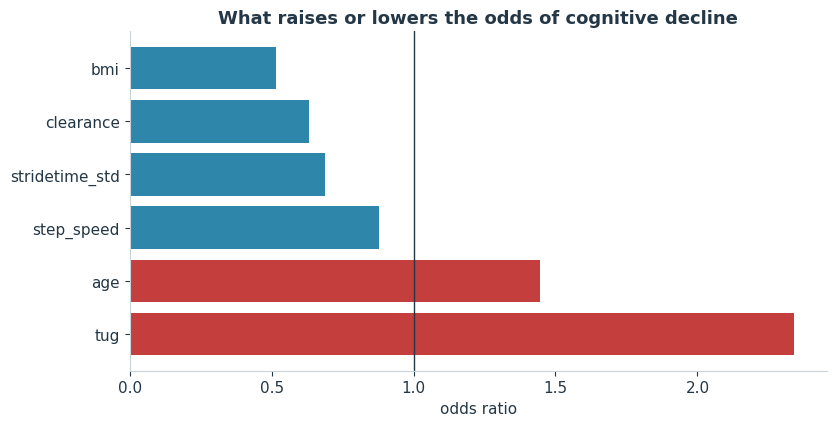

Strongest and statistically reliable signals:
  bmi              OR=0.52  (lowers odds)  <-- reliable
  clearance        OR=0.63  (lowers odds)
  stridetime_std   OR=0.69  (lowers odds)
  step_speed       OR=0.88  (lowers odds)
  age              OR=1.45  (raises odds)
  tug              OR=2.34  (raises odds)  <-- reliable


In [ ]:
Xi = X.fillna(X.median())
Xz = pd.DataFrame(StandardScaler().fit_transform(Xi), columns=FEATURES)
mdl = sm.Logit(y, sm.add_constant(Xz)).fit(disp=0)

odds = pd.DataFrame({"feature": FEATURES,
                     "OR": np.exp(mdl.params[FEATURES]).values,
                     "p":  mdl.pvalues[FEATURES].values}).sort_values("OR")
colors = [POS if v>1 else NEG for v in odds["OR"]]
fig, ax = plt.subplots(figsize=(8.5, 4.4))
hbar(ax, odds["feature"], odds["OR"], colors, "What raises or lowers the odds of cognitive decline", "odds ratio")
ax.axvline(1, color=INK, lw=1)
plt.tight_layout(); plt.show()

print("Strongest and statistically reliable signals:")
for _, r in odds.iterrows():
    star = "  <-- reliable" if r["p"]<0.05 else ""
    arrow = "raises" if r["OR"]>1 else "lowers"
    print(f"  {r['feature']:<16} OR={r['OR']:.2f}  ({arrow} odds){star}")

**The headline:** a **slower Timed Up and Go** is by far the strongest sign of cognitive decline, backed up by generally slower, shorter, lower-clearance walking. This is exactly the hesitant, shuffling pattern a clinician would recognise, so the model found something medically sensible, not a fluke.

## Step 13 — How do the three tasks relate?

We used the **same walking measurements** for all three tasks. Do they flag the same people? We compare each person's risk scores across tasks.

Two pictures:
- a **heatmap** of how strongly the three risk scores agree, and
- a **scatter** of dementia risk vs frailty risk, one dot per person.

**Why this matters:** if dementia were just frailty in disguise, its risk score would match frailty almost perfectly. If it stands somewhat apart, the walk carries a *brain-specific* signal.

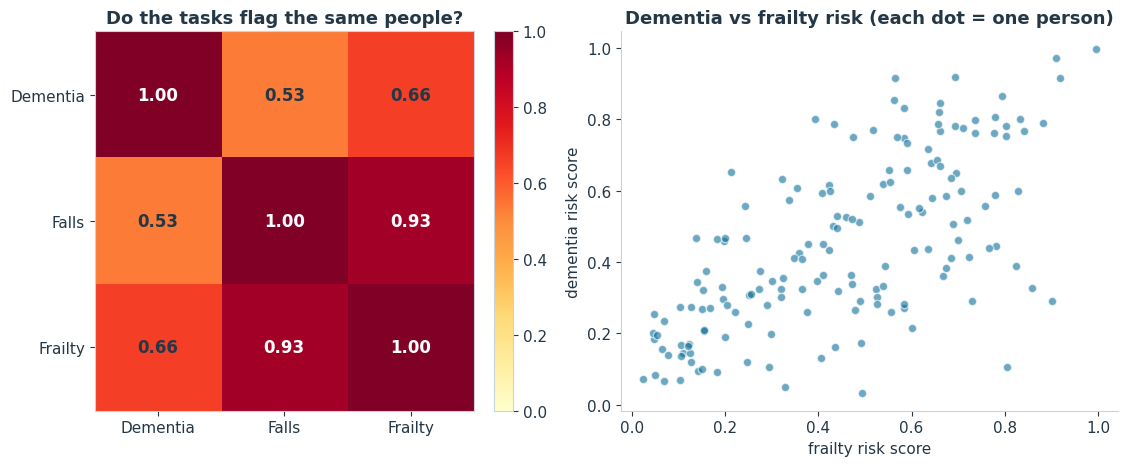

Falls and frailty agree almost perfectly (~0.9) - basically one 'physical' signal.
Dementia agrees only moderately (~0.5-0.7) - related, but its own distinct signal.
=> the walk carries brain information beyond plain physical frailty. That is the contribution.


In [ ]:
probs = {}
for tname, yy in TARGETS.items():
    probs[tname] = cross_val_predict(make_models()["Logistic Regression"], X, yy,
                    cv=StratifiedKFold(5, shuffle=True, random_state=1), method="predict_proba")[:,1]
names = list(TARGETS)
M = np.array([[pearsonr(probs[a], probs[b])[0] for b in names] for a in names])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
im = axes[0].imshow(M, cmap="YlOrRd", vmin=0, vmax=1)
axes[0].set_xticks(range(3)); axes[0].set_xticklabels(names)
axes[0].set_yticks(range(3)); axes[0].set_yticklabels(names)
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, f"{M[i,j]:.2f}", ha="center", va="center",
                     color="white" if M[i,j]>0.7 else INK, fontsize=12, fontweight="bold")
axes[0].set_title("Do the tasks flag the same people?")
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

axes[1].scatter(probs["Frailty"], probs["Dementia"], c=PRIMARY, alpha=0.6, edgecolor="white")
axes[1].set_xlabel("frailty risk score"); axes[1].set_ylabel("dementia risk score")
axes[1].set_title("Dementia vs frailty risk (each dot = one person)"); style_ax(axes[1])
plt.tight_layout(); plt.show()

print("Falls and frailty agree almost perfectly (~0.9) - basically one 'physical' signal.")
print("Dementia agrees only moderately (~0.5-0.7) - related, but its own distinct signal.")
print("=> the walk carries brain information beyond plain physical frailty. That is the contribution.")

## Step 14 — What we found, and its limits

**What we showed**
- From nothing but the way a person walks, a simple, explainable model flags signs of cognitive decline reasonably well (about 0.75 AUC, catching roughly two thirds of cases).
- The strongest single sign is a slower Timed Up and Go test.
- This cognitive signal is **separate** from ordinary physical frailty, which is the key point for the psychointelligence idea: the mind shows up in movement, not just the body.

**Honest limits**
- It is a **screening signal, not a diagnosis**. Only a clinician can diagnose dementia.
- It is a **small study** (163 people), so it must be repeated on a larger, more varied group.
- It is a **snapshot**: we measured walking and cognition at the same time, so we cannot yet say walking predicts future decline.
- It shows **association, not cause**.

**A good next step:** nested cross-validation (a stricter test that stops the model-choosing step from flattering the scores), which would make these numbers fully publication-ready.